In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Conv1D, Dropout, Add, Flatten
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler

# =====================================================================
# 1. ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU
# =====================================================================
# Giả định file VCB_data.csv có ít nhất 2 cột: 'Date' và 'Close' (Giá đóng cửa)
from load_data import load_vcb_data
df = load_vcb_data()
df = df.sort_index()  # Sắp xếp theo trình tự thời gian tăng dần

# Lấy chuỗi giá đóng cửa để thực hiện dự đoán
data = df['Close'].values.reshape(-1, 1)

# Chuẩn hóa dữ liệu về khoảng [0, 1] để mô hình hội tụ nhanh hơn
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Hàm tạo chuỗi dữ liệu (X: chuỗi ngày quá khứ, y: giá ngày kế tiếp)
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

LOOKBACK = 30  # Dùng dữ liệu của 30 ngày trước để dự đoán ngày tiếp theo
X, y = create_sequences(scaled_data, LOOKBACK)

# Chia dữ liệu theo tỷ lệ 80% Train / 20% Test (Không chia ngẫu nhiên để giữ tính liên tục)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# =====================================================================
# 2. XÂY DỰNG KHỐI TCN RESIDUAL BLOCK (Theo đúng sơ đồ kiến trúc)
# =====================================================================
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):
    # Tầng tích chập nhân quả thứ 1 (Causal Conv) kèm giãn nhóm (Dilation)
    res = Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', 
                 dilation_rate=dilation_rate, activation='relu')(x)
    res = Dropout(dropout_rate)(res)
    
    # Tầng tích chập nhân quả thứ 2
    res = Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', 
                 dilation_rate=dilation_rate, activation='relu')(res)
    res = Dropout(dropout_rate)(res)
    
    # Nhánh Optional 1x1 Convolution nếu kích thước kênh đầu vào và đầu ra không khớp
    if x.shape[-1] != filters:
        x = Conv1D(filters=filters, kernel_size=1, padding='same')(x)
        
    return Add()([x, res])  # Khớp nối Cộng Residual (Shortcut connection)

# =====================================================================
# 3. KẾT NỐI MÔ HÌNH HOÀN CHỈNH
# =====================================================================
inputs = Input(shape=(LOOKBACK, 1))

# Tạo chuỗi các tầng Residual với dilation_rate tăng dần theo cấp số nhân (1, 2, 4)
x = tcn_residual_block(inputs, filters=64, kernel_size=3, dilation_rate=1)
x = tcn_residual_block(x, filters=64, kernel_size=3, dilation_rate=2)
x = tcn_residual_block(x, filters=64, kernel_size=3, dilation_rate=4)

x = Flatten()(x)
outputs = Dense(1)(x)  # Đầu ra dự đoán 1 giá trị liên tục (giá ngày tiếp theo)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

# =====================================================================
# 4. HUẤN LUYỆN MÔ HÌNH
# =====================================================================
print("\n--- Bắt đầu huấn luyện mô hình TCN ---")
history = model.fit(
    X_train, y_train, 
    epochs=30, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)

# =====================================================================
# 5. DỰ ĐOÁN VÀ ĐÁNH GIÁ KẾT QUẢ
# =====================================================================
predictions = model.predict(X_test)
# Đảo ngược quá trình chuẩn hóa để đưa giá trị về đơn vị tiền tệ gốc (VND)
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

model.save('../models/vcb_tcn_model.h5')
print("Đã lưu mô hình thành công vào file vcb_tcn_model.h5!")

2026-07-24 01:37:41.402 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
d:\AdyFinal\database.py:142: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 30, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 30, 64)    │     12,352 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 64)    │          0 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 30, 64)    │     12,352 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 64)    │          0 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 64)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1920)      │          0 │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      1,921 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 64,065 (250.25 KB)

 Trainable params: 64,065 (250.25 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu huấn luyện mô hình TCN ---
Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0373 - mae: 0.1298 - val_loss: 0.0033 - val_mae: 0.0392
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0065 - mae: 0.0583 - val_loss: 0.0021 - val_mae: 0.0281
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0047 - mae: 0.0505 - val_loss: 0.0017 - val_mae: 0.0247
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - mae: 0.0426 - val_loss: 0.0014 - val_mae: 0.0231
Epoch 5/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - mae: 0.0386 - val_loss: 0.0017 - val_mae: 0.0300
Epoch 6/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025 - mae: 0.0356 - val_loss: 0.0013 - val_mae: 0.0232
Epoch 7/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - mae: 0.0324 - val_loss: 0.0011 - val_mae: 0.0211
Epoch 8/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - mae: 0.0311 - val_loss: 0.0010 - val_mae: 0.0204
Epoch 9/30
41/41 ━━━━━━━━━━━━━━

Đã lưu mô hình thành công vào file vcb_tcn_model.h5!


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================
MAE (Sai số tuyệt đối trung bình): 783.61 VND
RMSE (Sai số căn phương sai trung bình): 1,333.06 VND
MAPE (Phần trăm sai số tuyệt đối trung bình): 1.26%


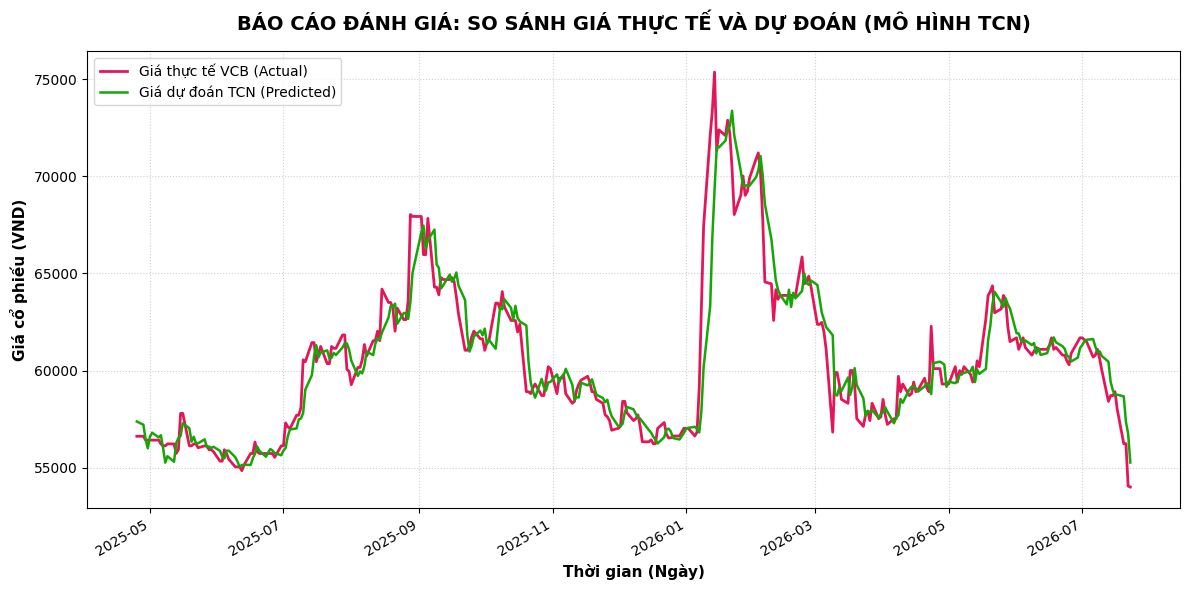

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================================
# 5. DỰ ĐOÁN VÀ ĐẢO NGƯỢC CHUẨN HÓA (Đã có ở phần trước)
# =====================================================================
predictions = model.predict(X_test)
predictions_actual = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

# =====================================================================
# 6. TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ (Evaluation Metrics)
# =====================================================================
mae = mean_absolute_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100

print("\n================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================")
print(f"MAE (Sai số tuyệt đối trung bình): {mae:,.2f} VND")
print(f"RMSE (Sai số căn phương sai trung bình): {rmse:,.2f} VND")
print(f"MAPE (Phần trăm sai số tuyệt đối trung bình): {mape:.2f}%")
print("==========================================================")

# =====================================================================
# 7. VẼ BIỂU ĐỒ ĐƯỜNG TRỰC QUAN HÓA KẾT QUẢ
# =====================================================================
# Trích xuất các mốc ngày tương ứng với tập Test để làm trục hoành (X-axis)
test_dates = df.index[-len(y_test_actual):]

plt.figure(figsize=(12, 6))

# Vẽ đường giá thực tế và giá dự đoán
plt.plot(test_dates, y_test_actual, label='Giá thực tế VCB (Actual)', color="#E61557", linewidth=2)
plt.plot(test_dates, predictions_actual, label='Giá dự đoán TCN (Predicted)', color="#15A705", linewidth=1.8)

# Định dạng cấu trúc biểu đồ
plt.title('BÁO CÁO ĐÁNH GIÁ: SO SÁNH GIÁ THỰC TẾ VÀ DỰ ĐOÁN (MÔ HÌNH TCN)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Ngày)', fontsize=11, fontweight='bold')
plt.ylabel('Giá cổ phiếu (VND)', fontsize=11, fontweight='bold')

# Hiển thị chú thích (Legend) và lưới nền (Grid)
plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Tự động xoay ngày tháng trên trục X nếu quá dày để tránh đè chữ
plt.gcf().autofmt_xdate()

# Hiển thị biểu đồ lên màn hình
plt.tight_layout()
plt.show()